In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import mlflow
import matplotlib.pyplot as plt
%matplotlib widget

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from sysid.data import DataNormalizer

print(f"Project root: {project_root}")


Project root: /Users/jack/Documents/01_Git/01_promotion/genSecSysId/python


In [2]:
# Set MLflow tracking URI
mlflow_uri = project_root / "mlruns"
mlflow.set_tracking_uri(f"file://{mlflow_uri}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")


MLflow tracking URI: file:///Users/jack/Documents/01_Git/01_promotion/genSecSysId/python/mlruns


In [30]:
# Define run IDs with internal labels (modify as needed)
# Map: internal_id -> run_id
RUN_ID_MAP = {
    'MyID_10': 'f4358c9da13a480d97be4cce7312e03c',
    'MyID_8': '9803b92d9c9240afb3e4628bb7df7cca',
    # 'MyID_9': '8921e9bbe9054246b6fb63f3402ab78e',
    # 'MyID_13': '5e1f184c831b40f1a83e60f5f92f11a3'
}

print(f"Run IDs to compare: {RUN_ID_MAP}")


Run IDs to compare: {'MyID_10': 'f4358c9da13a480d97be4cce7312e03c', 'MyID_8': '9803b92d9c9240afb3e4628bb7df7cca'}


In [31]:
def load_evaluation_data(internal_id, run_id):
    """
    Load evaluation artifacts from a run.
    
    Args:
        internal_id: Internal label for the run
        run_id: MLflow run ID
        
    Returns:
        Dictionary with 'inputs', 'targets', 'predictions' numpy arrays
    """
    try:
        # Download all evaluation artifacts
        artifact_dir = mlflow.artifacts.download_artifacts(
            run_id=run_id, 
            artifact_path="evaluation"
        )
        
        # Load the arrays
        inputs = np.load(os.path.join(artifact_dir, "inputs.npy"))
        targets = np.load(os.path.join(artifact_dir, "targets.npy"))
        predictions = np.load(os.path.join(artifact_dir, "predictions.npy"))
        
        print(f"✓ {internal_id} ({run_id}):")
        print(f"  Inputs shape: {inputs.shape}")
        print(f"  Targets shape: {targets.shape}")
        print(f"  Predictions shape: {predictions.shape}")
        
        return {
            'internal_id': internal_id,
            'run_id': run_id,
            'inputs': inputs,
            'targets': targets,
            'predictions': predictions,
        }
    except Exception as e:
        print(f"✗ Failed to load {internal_id}: {e}")

        return None

In [32]:
def select_random_trajectories(data_dict, n_trajectories=5, seed=42):
    """
    Randomly select n trajectories from the data.
    
    Args:
        data_dict: Dictionary with 'inputs', 'targets', 'predictions'
        n_trajectories: Number of random trajectories to select
        seed: Random seed for reproducibility
        
    Returns:
        Dictionary with only selected trajectory indices and the corresponding data
    """
    np.random.seed(seed)
    
    n_total = data_dict['targets'].shape[0]
    n_select = min(n_trajectories, n_total)
    
    selected_indices = np.random.choice(n_total, size=n_select, replace=False)
    selected_indices = np.sort(selected_indices)
    
    return {
        'indices': selected_indices,
        'inputs': data_dict['inputs'][selected_indices],
        'targets': data_dict['targets'][selected_indices],
        'predictions': data_dict['predictions'][selected_indices],
    }


In [33]:
# Load evaluation data from all runs
runs_data = []
for internal_id, run_id in RUN_ID_MAP.items():
    data = load_evaluation_data(internal_id, run_id)
    if data is not None:
        runs_data.append(data)

print(f"\nSuccessfully loaded {len(runs_data)}/{len(RUN_ID_MAP)} runs")


✓ MyID_10 (f4358c9da13a480d97be4cce7312e03c):
  Inputs shape: (15, 4000, 1)
  Targets shape: (15, 4000, 1)
  Predictions shape: (15, 4000, 1)


✓ MyID_8 (9803b92d9c9240afb3e4628bb7df7cca):
  Inputs shape: (15, 4000, 1)
  Targets shape: (15, 4000, 1)
  Predictions shape: (15, 4000, 1)

Successfully loaded 2/2 runs


In [34]:
# Select random trajectories for comparison (5 per run)
selected_runs = []
for data in runs_data:
    selected = select_random_trajectories(data, n_trajectories=5, seed=42)
    selected['internal_id'] = data['internal_id']
    selected['run_id'] = data['run_id']
    selected_runs.append(selected)
    
print(f"\nSelected trajectories for each run:")
for selected in selected_runs:
    print(f"  {selected['internal_id']}: indices {selected['indices']}")



Selected trajectories for each run:
  MyID_10: indices [ 0  5  9 11 13]
  MyID_8: indices [ 0  5  9 11 13]


In [35]:
# Summary of loaded data
print("\n" + "="*60)
print("COMPARISON DATA SUMMARY")
print("="*60)

for i, selected in enumerate(selected_runs, 1):
    internal_id = selected['internal_id']
    print(f"\n{internal_id}:")
    print(f"  Selected trajectories: {selected['indices'].tolist()}")
    print(f"  Inputs shape: {selected['inputs'].shape}")
    print(f"  Targets shape: {selected['targets'].shape}")
    print(f"  Predictions shape: {selected['predictions'].shape}")

print("\n" + "="*60)
print("Data is ready for plotting in the next cell!")
print("="*60)



COMPARISON DATA SUMMARY

MyID_10:
  Selected trajectories: [0, 5, 9, 11, 13]
  Inputs shape: (5, 4000, 1)
  Targets shape: (5, 4000, 1)
  Predictions shape: (5, 4000, 1)

MyID_8:
  Selected trajectories: [0, 5, 9, 11, 13]
  Inputs shape: (5, 4000, 1)
  Targets shape: (5, 4000, 1)
  Predictions shape: (5, 4000, 1)

Data is ready for plotting in the next cell!



Comparing 2 runs...


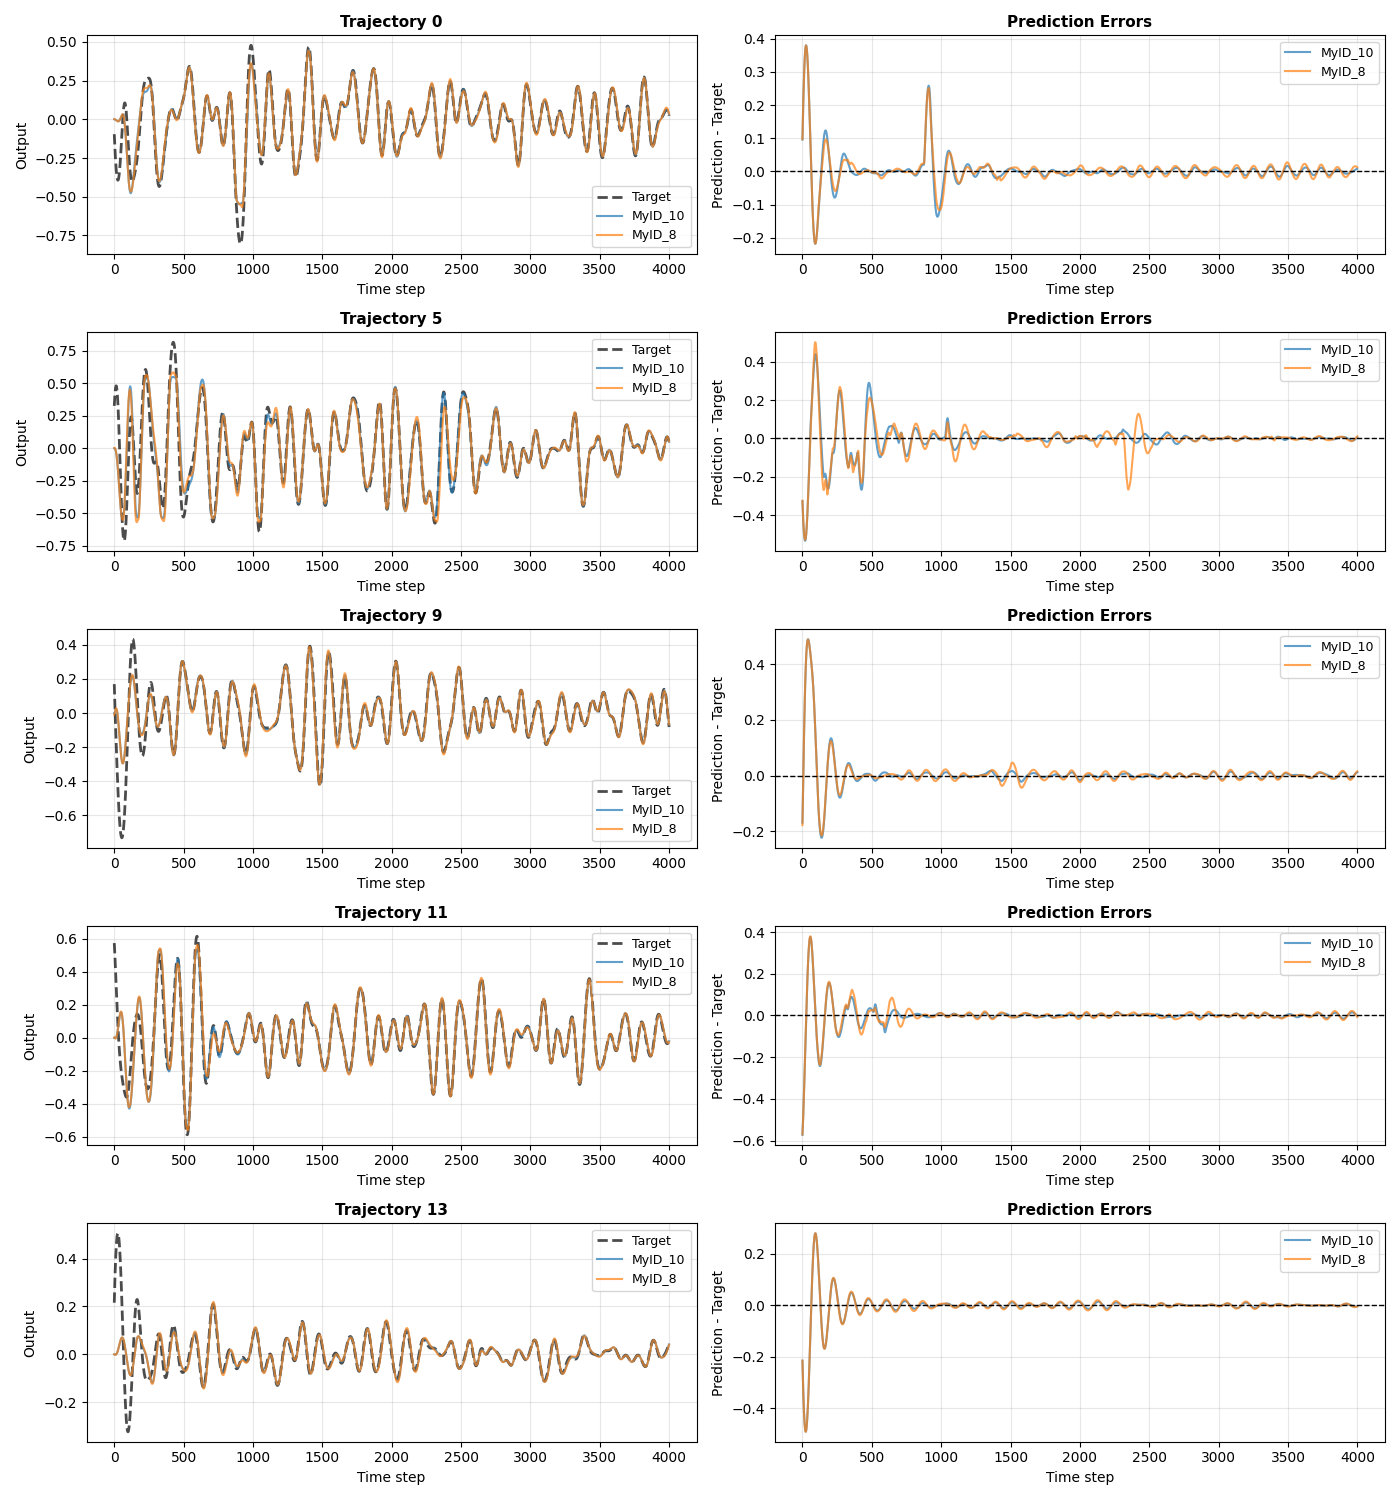

In [36]:
def plot_comparison_all_runs(selected_runs, n_trajectories=5):
    """
    Compare predictions from all runs for the same randomly selected trajectories.
    
    Args:
        selected_runs: List of dictionaries with selected trajectory data for each run
        n_trajectories: Number of trajectories to plot (typically 5)
    """
    fig, axes = plt.subplots(n_trajectories, 2, 
                              figsize=(14, 3 * n_trajectories))
    
    if n_trajectories == 1:
        axes = axes.reshape(1, -1)
    
    # Use the first run's targets (all runs should have the same targets)
    targets = selected_runs[0]['targets']
    target_indices = selected_runs[0]['indices']
    
    for traj_idx in range(n_trajectories):
        # Left column: target vs all predictions
        ax = axes[traj_idx, 0]
        y = targets[traj_idx]
        
        # Plot target once with dashed line
        ax.plot(y, '--', linewidth=2, label='Target', alpha=0.7, color='black')
        
        # Plot predictions from each run with solid lines and internal ID labels
        for run_idx, selected in enumerate(selected_runs):
            y_hat = selected['predictions'][traj_idx]
            ax.plot(y_hat, '-', linewidth=1.5, label=selected['internal_id'], alpha=0.7)
        
        ax.set_title(f"Trajectory {target_indices[traj_idx]}", fontsize=11, fontweight='bold')
        ax.set_ylabel('Output')
        ax.set_xlabel('Time step')
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
        
        # Right column: errors from all runs
        ax = axes[traj_idx, 1]
        
        for run_idx, selected in enumerate(selected_runs):
            y_hat = selected['predictions'][traj_idx]
            error = y_hat - y
            ax.plot(error, '-', linewidth=1.5, label=selected['internal_id'], alpha=0.7)
        
        ax.set_title(f"Prediction Errors", fontsize=11, fontweight='bold')
        ax.set_ylabel('Prediction - Target')
        ax.set_xlabel('Time step')
        ax.axhline(y=0, color='k', linestyle='--', linewidth=1)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, axes


# Plot all runs together for comparison
if selected_runs:
    print(f"\nComparing {len(selected_runs)} runs...")
    fig, axes = plot_comparison_all_runs(selected_runs, n_trajectories=5)
    plt.show()
else:
    print("No data loaded. Please add run IDs and run the previous cells first.")
